<a href="https://colab.research.google.com/github/sivacivil12345/SOCIAL-MEDIA-ANALYSIS-PYTHON-FUNDAMENDALS/blob/main/Python_main_assign_for_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     image       fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      reel          food  11750.0   
2    86820  32.0  Female      UK   109864      text          food   4862.0   
3    64886  51.0   Other  France   848877      text       fitness   5350.0   
4    16265  34.0   Other      UK   449706     image       fitness  12682.0   

   comments  shares  watch_time_sec  impression_count   posted_at  \
0     354.0  1157.0            5726             44650  17-12-2022   
1    2606.0  1807.0            5947             80216  02-06-2023   
2     344.0   955.0            6946             44858  07-05-2023   
3    1083.0  1049.0             229             70455  12-02-2023   
4    2735.0  1300.0            4798              6019  23-05-2023   

   follower_count  is_verified device_type sentiment               hashtags  \
0           81734        False      m

/tmp/ipykernel_8087/429444448.py:22: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['posted_at'] = pd.to_datetime(df['posted_at'])


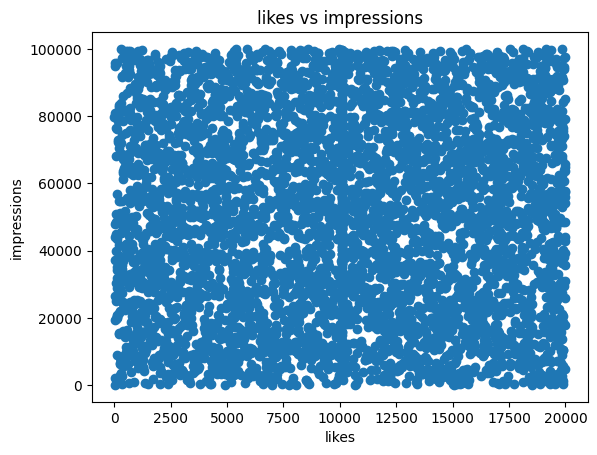

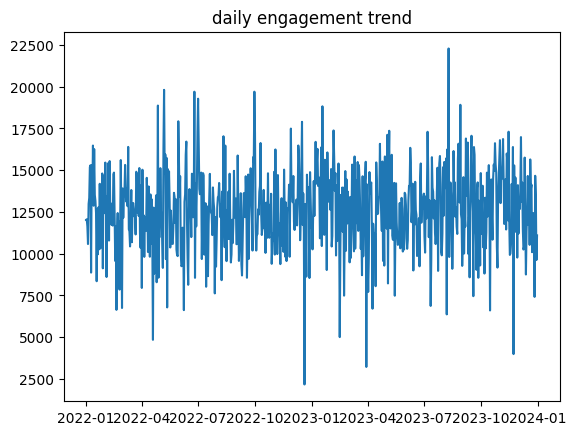

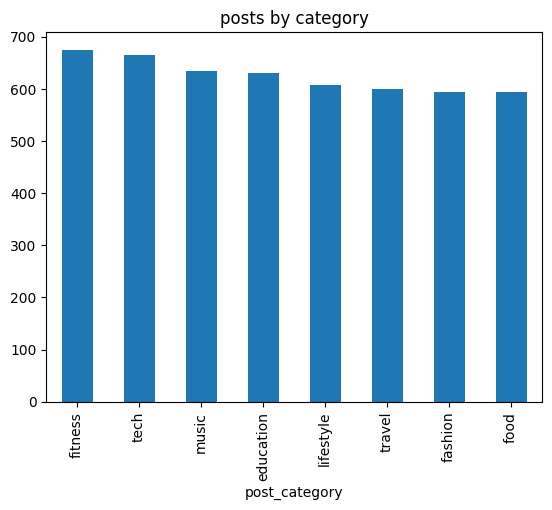

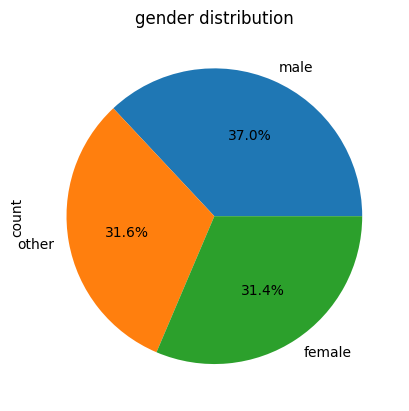

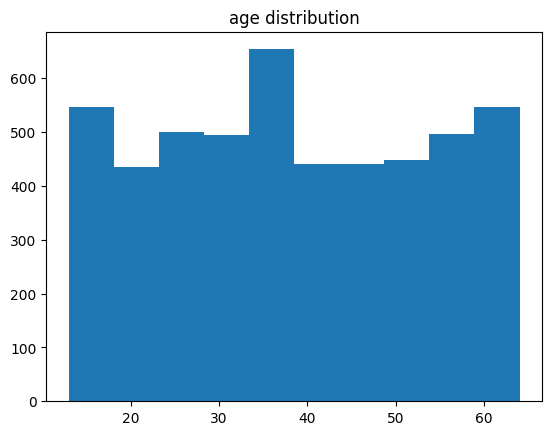

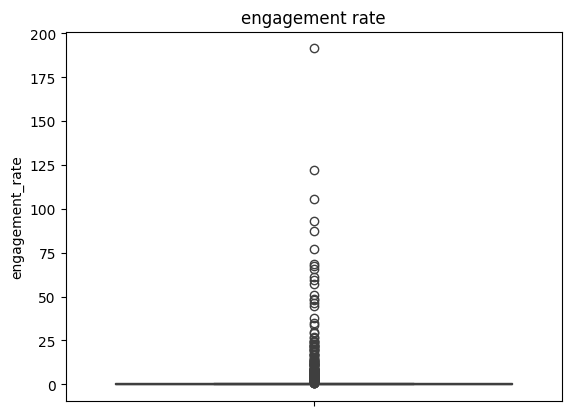

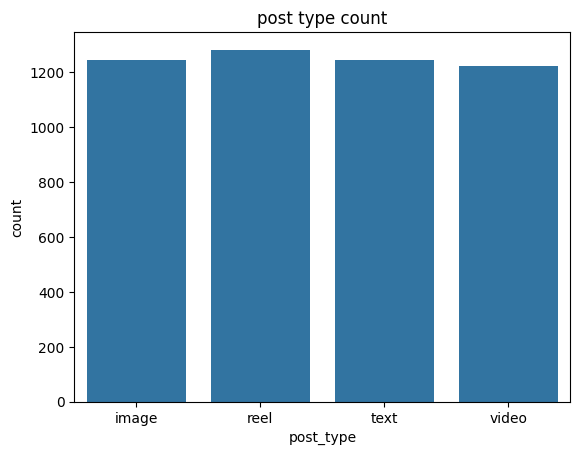

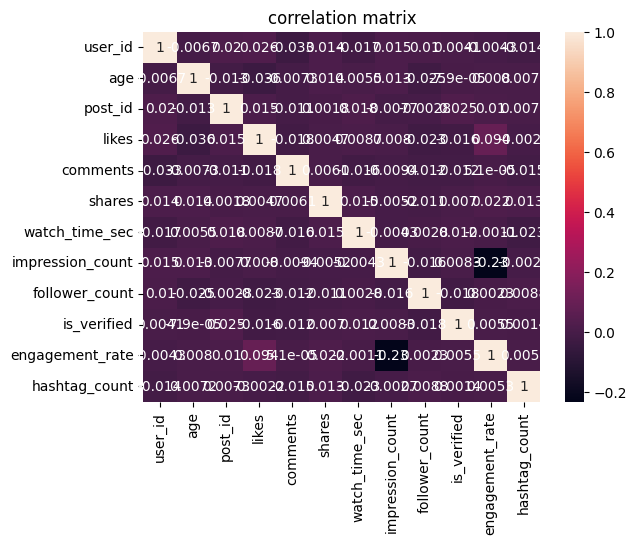

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 88.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 88.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 90.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 90.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


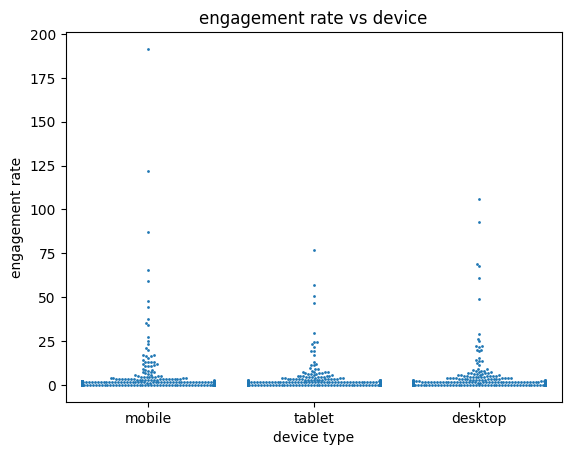

In [ ]:
# python for data analysis - social media engagement analytics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# load dataset
df=pd.read_csv('https://github.com/GeethaGunasekaran1/Dataset_rep/raw/refs/heads/main/social_media_engagement_5000.csv')

# view dataset
print(df.head())
print(df.shape)
print(df.columns)

# check data types
print(df.info())
print(df.dtypes)

# convert data column
df['posted_at'] = pd.to_datetime(df['posted_at'])

print(df['posted_at'].head())

print(df.isnull().sum())

df['likes']=df['likes'].fillna(df['likes'].median())
df['comments']=df['comments'].fillna(df['comments'].median())
df['shares']=df['shares'].fillna(df['shares'].median())
df['age']=df['age'].fillna(df['age'].median())
df['gender']=df['gender'].fillna(df['gender'].mode()[0])
df['sentiment']=df['sentiment'].fillna(df['sentiment'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])

df.drop_duplicates(inplace=True)

df['likes']=df['likes'].apply(lambda x: abs(x))
df['shares']=df['shares'].apply(lambda x: abs(x))

df['gender']=df['gender'].str.lower()
df['gender']=df['gender'].replace({
    'm':'male',
    'f':'female'
})

df['hashtag_count']=df['hashtags'].apply(
    lambda x: len(str(x).split())
)


df['sentiment']=df['sentiment'].str.lower().str.strip()

print(df.head())
print(df.tail())
print(df.shape)
print(df.describe())


print(df['post_type'].value_counts())
print(df['country'].nunique())
print(df['country'].unique())

corr_matrix=df.corr(numeric_only=True)
print(corr_matrix)

print(df.groupby('post_type')['likes'].mean())

print(df.groupby('country')['impression_count'].mean()) # corrected column name

df['engagement_score']=(
    df['likes']+
    df['comments']+
    df['shares']
)


df['lod_likes']=np.log1p(df['likes'])


summary=df.groupby(
    ['post_type','country']
)[['likes','comments','shares']].mean()

print(summary)


columns=[
    'likes',
    'comments',
    'shares',
    'watch_time_sec',
    'engagement_rate',
    'follower_count'
]

for col in columns:
  print(f"\nstatistics for {col}")

  print("mean:",df[col].mean())
  print("median:",df[col].median())
  print("mode:",df[col].mode()[0])
  print("std:",df[col].std())
  print("variance:",df[col].var())

  print('percentiles:')
  print(df[col].quantile([0.25,0.5,0.75]))



print(df[columns].skew())
print(df[columns].kurt())


plt.scatter(df['likes'],df['impression_count'])
plt.xlabel('likes')
plt.ylabel('impressions')
plt.title('likes vs impressions')
plt.show()


daily = df.groupby('posted_at')['engagement_score'].mean()

plt.plot(daily)
plt.title('daily engagement trend')
plt.show()

df['post_category'].value_counts().plot(kind='bar')
plt.title('posts by category')
plt.show()


df['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('gender distribution')
plt.show()

plt.hist(df['age'])
plt.title('age distribution')
plt.show()


sns.boxplot(y=df['engagement_rate'])
plt.title('engagement rate')
plt.show()

sns.countplot(x='post_type',data=df)
plt.title('post type count')
plt.show()

sns.heatmap(corr_matrix,annot=True)
plt.title('correlation matrix')
plt.show()


import seaborn as sns
import matplotlib.pyplot as plt

sns.swarmplot(
    x='device_type',
    y='engagement_rate',
    data=df,
    s=2 # reduce marker size
)

plt.title('engagement rate vs device')
plt.xlabel('device type')
plt.ylabel('engagement rate')

plt.show()

fig=px.scatter(df,x='likes',y='impression_count',color='post_type',size='shares',hover_data=['country'])

fig.show()